# チェビシェフ多項式の説明とCompEconでの実装の紹介

このNotebookでは、[『定量的マクロ経済学と数値計算』](https://www.nippyo.co.jp/blogkeisemi/booksupport_guide/quantmacro/)の補論B.1.3をもとにチェビシェフ多項式について説明し、[CompEcon（ここではJuliaのパッケージ）](https://github.com/mizuhirosuzuki/CompEcon.jl)を用いた実際の計算について説明する。

In [4]:
# Run this for importing the CompEcon package

# using Pkg
# Pkg.add(url="https://github.com/mizuhirosuzuki/CompEcon.jl")

In [2]:
using CompEcon
using Plots

チェビシェフ多項式を使った、関数$g$の近似$g(x; \theta)$を考える：

$$
    g(x; \theta) = \theta_0 + \theta_1 T_1(x) + \cdots + \theta_{N-1} T_{N-1}(x)
$$

ただし$x \in [-1, 1]$.
基底関数$T_i$ $(i = 1, 2, \dots, N-1)$は教科書p.243にあるように再帰的に求められる。

近似に必要な情報はN個のパラメータ ($\theta_0, \theta_1, \dots, \theta_{N-1}$) なので、N個の評価点　（選点：collocation points）とそこでの関数の値を使ってパラメータを求める。
教科書p.244では選点の選び方としてチェビシェフゼロ点とチェビシェフ極値点が紹介されているが、その他の点の取り方もできる（例えば-1と1の間の点を等間隔に取ったり）。

選点をN個（$x_0, x_1, \dots, x_{N-1}$）取ってきたら、以下の線形連立方程式をかける：

$$
    \begin{bmatrix}
g(x_0) \\
g(x_1) \\
\vdots \\
g(x_{N-1})
\end{bmatrix} = = \begin{bmatrix}
1 & T_1(x_0) & T_2(x_0) & \cdots & T_{N-1}(x_0) \\
1 & T_1(x_1) & T_2(x_1) & \cdots & T_{N-1}(x_1) \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & T_1(x_{N-1}) & T_2(x_{N-1}) & \cdots & T_{N-1}(x_{N-1})
\end{bmatrix}
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_{N-1}
\end{bmatrix}
$$

右辺の大きい$N \times N$の行列の逆行列を取って左辺に掛ければ、パラメータは求められる。


## CompEconでの実装

ここでは[パッケージのページ](https://github.com/mizuhirosuzuki/CompEcon.jl)にある例に従って、$f(x) = \exp(x)$を近似することを考える。
近似の定義域は-1から1とするが、これである必要はない（教科書p.245にあるように、簡単な変換を使って任意の定義域を使うことができる）。

In [5]:
# function to approximate
f(x) = exp.(-x)

# Set the endpoints of approximation interval:
a =  -1                            # left endpoint
b =   1                            # right endpoint

1

まず、グリッド（選点）の数と定義域の情報を使って、`basis`を求める。
基底関数や変換といった、近似に必要な情報がここで求められる。

In [6]:
# Choose an approximation scheme. In this case, let us use an order 10
# Chebychev approximation scheme:
n = 10                             # order of approximation
basis = fundefn(:cheb, n, a, b)      # define basis

Dict{Symbol, Any} with 8 entries:
  :a             => [-1.0]
  :b             => [1.0]
  :d             => 1
  :n             => [10]
  :params        => Any[Any[10, -1.0, 1.0]]
  :_basis_params => BasisParams[Chebyshev interpoland parameters with 10 basis …
  :basetype      => [:cheb]
  :_basis        => 1 dimensional Basis on the hypercube formed by (-1.0,) × (1…

ここから、チェビシェフ多項式のパラメータを求めていく。
これには主に二つの方法がある。
まず一つ目は、選点を求め、その上での評価値を求め、上の線型方程式を解いてパラメータを求める方法。
選点にはチェビシェフゼロ点を使っているよう。

In [7]:
# ... or one may compute the standard approximation nodes x and corresponding
# function values y and use funfitxy:
x = funnode(basis)[1]
y = f(x)
c = funfitxy(basis, x, y)[1]

10-element Vector{Float64}:
  1.2660658777520082
 -1.13031820798497
  0.27149533953407656
 -0.04433684984866376
  0.005474240442093727
 -0.0005429263119138909
  4.4977322952919744e-5
 -3.19843642248917e-6
  1.992114415098184e-7
 -1.1011792203789759e-8

二つ目は、関数を直接使ってパラメータを求める方法。
ここでは選点は勝手に選んでくれる。

In [8]:
# Compute the basis coefficients c.  There are various way to do this:
# One may use funfitf:
c = funfitf(basis, f)

10-element Vector{Float64}:
  1.2660658777520082
 -1.13031820798497
  0.27149533953407656
 -0.04433684984866376
  0.005474240442093727
 -0.0005429263119138909
  4.4977322952919744e-5
 -3.19843642248917e-6
  1.992114415098184e-7
 -1.1011792203789759e-8

得られたパラメータは`funeval`という関数の中で、新たな評価点での値を求めるために使うことができる。
例えば$x=0$での値を求めるには以下のようにする

In [9]:
funeval(c, basis, [0.0])[1]

1×1 Matrix{Float64}:
 1.000000000548514

下のグラフでは近似の精度を評価している。
選点以外の点でも関数がうまく近似されていることがわかる。

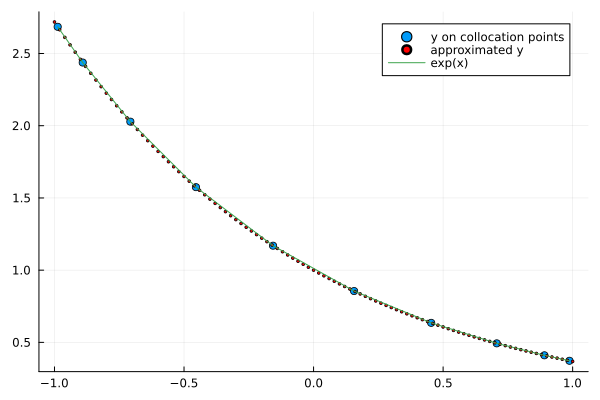

In [10]:
x_granular = -1:0.02:1
plot(x, funeval(c, basis, x)[1], seriestype=:scatter, label="y on collocation points")
plot!(x_granular, funeval(c, basis, x_granular)[1], seriestype=:scatter, label="approximated y", ms=1.5, mc=:red)
plot!(x, f(x), label="exp(x)")

また、上で見た基底関数からなる$N \times N$の行列は`funbase`によって求めることができる。

In [ ]:
funbase(basis)

10×10 Matrix{Float64}:
 1.0  -0.987688   0.951057     -0.891007  …  -0.45399    0.309017  -0.156434
 1.0  -0.891007   0.587785     -0.156434      0.987688  -0.809017   0.45399
 1.0  -0.707107   2.22045e-16   0.707107     -0.707107   1.0       -0.707107
 1.0  -0.45399   -0.587785      0.987688     -0.156434  -0.809017   0.891007
 1.0  -0.156434  -0.951057      0.45399       0.891007   0.309017  -0.987688
 1.0   0.156434  -0.951057     -0.45399   …  -0.891007   0.309017   0.987688
 1.0   0.45399   -0.587785     -0.987688      0.156434  -0.809017  -0.891007
 1.0   0.707107  -2.22045e-16  -0.707107      0.707107   1.0        0.707107
 1.0   0.891007   0.587785      0.156434     -0.987688  -0.809017  -0.45399
 1.0   0.987688   0.951057      0.891007      0.45399    0.309017   0.156434

ちなみに、`funnode`によるチェビシェフゼロ点を使わず、自分で決めたグリッドを使うこともできる。
この場合、一つ目の方法で$x$として自分の決めたグリッドを与えることでパラメータが得られる

In [95]:
x_grid = -1:0.1:1
y_grid = f(x_grid)
basis_grid = fundefn(:cheb, length(x_grid), a, b)
c_grid = funfitxy(basis_grid, x_grid, y_grid)[1]

21-element Vector{Float64}:
  1.2660658777521008
 -1.1303182079849454
  0.2714953395342421
 -0.04433684984864434
  0.005474240442206046
 -0.0005429263119035077
  4.4977322992774995e-5
 -3.1984364625191563e-6
  1.992124447400984e-7
 -1.103678112823048e-8
  5.505000080998373e-10
 -2.4993980554165644e-11
  9.311715399419616e-13
 -5.411750057626902e-14
 -9.020832845483969e-14
 -1.014798343042672e-14
 -5.617500015513166e-14
 -4.8829111784511995e-15
 -2.287614155589261e-14
 -1.2268211691306982e-15
 -4.705618424154547e-15

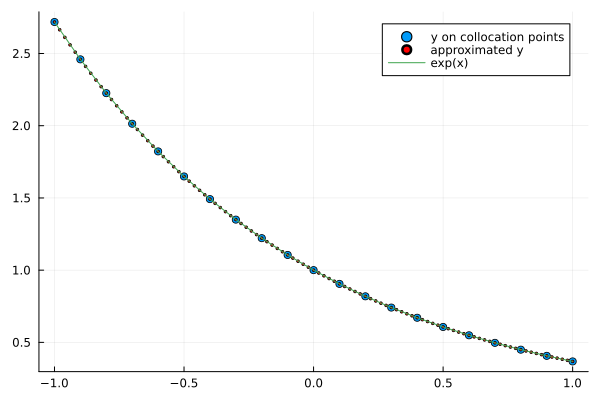

In [99]:
x_granular = -1:0.02:1
plot(x_grid, funeval(c_grid, basis_grid, x_grid)[1], seriestype=:scatter, label="y on collocation points")
plot!(x_granular, funeval(c_grid, basis_grid, x_granular)[1], seriestype=:scatter, label="approximated y",  ms=1.5, mc=:red)
plot!(x_grid, f(x_grid), label="exp(x)")